In [4]:
print ("hi")

hi


In [ ]:
from astropy.io import fits
import numpy as np
from astropy.wcs import WCS

# Open the TS Map file
hdul = fits.open('110906925_TSMap.fits')
ts_data = hdul[0].data
header = hdul[0].header

# Get the coordinate system math from the header
wcs = WCS(header)

# Find the exact pixel (x, y) with the highest TS score
max_y, max_x = np.unravel_index(np.argmax(ts_data, axis=None), ts_data.shape)
max_ts_value = ts_data[max_y, max_x]

#  Convert that pixel into RA & Dec
ra, dec = wcs.pixel_to_world_values(max_x, max_y)

print(f"Highest TS Score: {max_ts_value:.2f}")
print(f"Flare RA:  {ra:.3f} degrees")
print(f"Flare Dec: {dec:.3f} degrees")

Highest TS Score: 1129.43
Flare RA:  165.058 degrees
Flare Dec: 6.512 degrees


Set MJD-END to 55810.949306 from DATE-END'. [astropy.wcs.wcs]


In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.coordinates import frames, get_earth

#  Define the exact time of the flare
flare_time = "2011-09-06T22:11:00"

# Figure out where Earth was at that exact moment
earth_observer = get_earth(flare_time)

# Get the exact distance from Earth to the Sun
distance_to_sun = earth_observer.radius

#  Create the astropy coordinate object, but this time WITH the distance
flare_celestial = SkyCoord(ra*u.deg, dec*u.deg, distance=distance_to_sun, frame='icrs', obstime=flare_time)

# Set up the Helioprojective coordinate frame
hpc_frame = frames.Helioprojective(observer=earth_observer, obstime=flare_time)

#  Transform the coordinates
flare_hpc = flare_celestial.transform_to(hpc_frame)

print(f"Helio X: {flare_hpc.Tx.to(u.arcsec):.1f}")
print(f"Helio Y: {flare_hpc.Ty.to(u.arcsec):.1f}")

Helio X: 322.6 arcsec
Helio Y: 222.9 arcsec


Attempt to plot ts map, make the FOV biger

In [ ]:
import matplotlib.pyplot as plt

#  Open the TS Map file
hdul = fits.open('110906925_TSMap.fits')
ts_data = hdul[0].data
header = hdul[0].header


Set MJD-END to 55810.949306 from DATE-END'. [astropy.wcs.wcs]


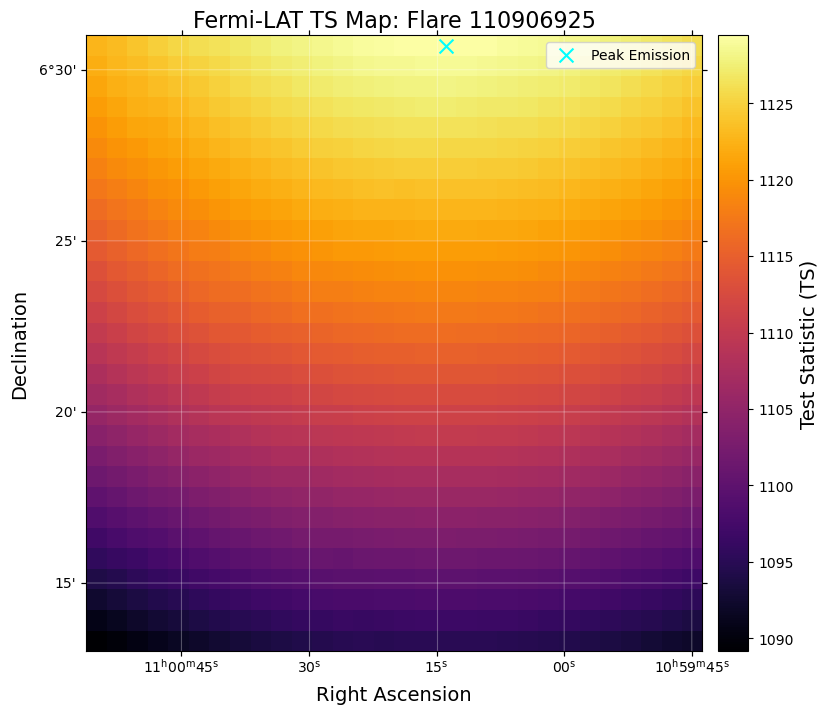

In [ ]:
# Get the World Coordinate System 
wcs = WCS(header)

#  Set up the figure and use WCS projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection=wcs)

#  Plot heat map
im = ax.imshow(ts_data, origin='lower', cmap='inferno')

# Add a colorbar so we know what TS score the colors represent
cbar = plt.colorbar(im, pad=0.02)
cbar.set_label('Test Statistic (TS)', fontsize=14)

#  labels
ax.grid(color='white', ls='solid', alpha=0.3)
ax.set_xlabel('Right Ascension', fontsize=14)
ax.set_ylabel('Declination', fontsize=14)
ax.set_title('Fermi-LAT TS Map: Flare 110906925', fontsize=16)

#  Find the brightest pixel to put a marker on it
max_y, max_x = np.unravel_index(np.argmax(ts_data, axis=None), ts_data.shape)
ax.scatter(max_x, max_y, marker='x', color='cyan', s=100, label='Peak Emission')
ax.legend()

plt.show()